In [1]:
!pip install xgboost


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================
# Cell 1: Import Required Libraries
# ==========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [3]:
# ==========================================
# Cell 1: Reload Original Clean Dataset
# ==========================================

df = pd.read_csv(r"click_fraud_dataset.csv")

print("Dataset Reloaded Successfully")
print("Shape:", df.shape)

df.head()


Dataset Reloaded Successfully
Shape: (5000, 21)


,click_id,timestamp,user_id,ip_address,device_type,browser,operating_system,referrer_url,page_url,click_duration,...,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,d875835d-3a4a-4a20-b0d1-6cddf89afc6a,2024-08-23 02:47:39,65a2f621-707b-49be-9c3e-ccac0b1d89ef,141.36.49.37,Tablet,Safari,Android,https://evans-ford.com/,http://www.turner-stewart.com/,0.29,...,111,8,Bottom,7,72,Good,0,1,0.29,0
1,a2d3f028-7790-4be1-9f75-df1357edbbdb,2025-01-30 23:23:50,135e0114-76c5-43ea-bdef-80ab537dc009,216.29.19.201,Desktop,Opera,iOS,https://pierce-ferguson.net/,http://www.rodriguez.biz/,0.64,...,452,29,Bottom,9,201,Suspicious,0,0,0.74,0
2,36d787b2-fbce-43ef-8c02-7c8746d7e3db,2025-01-21 05:41:12,a6922984-78cb-4c01-9c88-bfe3a13a0aaf,167.133.41.231,Tablet,Safari,Linux,https://www.martinez.com/,https://beck.biz/,0.42,...,431,18,Bottom,9,326,Good,0,1,0.14,0
3,01fc0078-096b-4f90-82ae-aa8085b719ac,2024-10-12 08:18:14,d30788b2-4048-4770-a4b1-a9358788818f,216.146.33.78,Tablet,Edge,macOS,https://jones-mendoza.com/,https://www.alvarado.com/,4.29,...,472,37,Side,4,33,Suspicious,0,0,0.65,0
4,0afdf2af-0b48-47d5-bfb6-e087053e1eb9,2024-04-19 14:44:35,dfc42287-6325-4344-b373-b8e61ea6e5c1,146.37.54.245,Desktop,Opera,Windows,https://www.griffith-holloway.com/,http://gonzalez.com/,2.46,...,50,2,Side,7,97,Good,0,0,0.06,0


In [ ]:
# ==========================================
# Cell 2: Add Controlled Feature Noise
# ==========================================

np.random.seed(42)

# Add noise to behavioral features
behavioral_features = [
    "click_frequency",
    "time_since_last_click"
]

for col in behavioral_features:
    noise = np.random.normal(
        0,
        0.05 * df[col].std(),   # 5% noise
        len(df)
    )
    df[col] = df[col] + noise
    df[col] = df[col].clip(lower=0)

# Add stronger noise to bot score (10%)
bot_noise = np.random.normal(
    0,
    0.10 * df["bot_likelihood_score"].std(),
    len(df)
)

df["bot_likelihood_score"] = df["bot_likelihood_score"] + bot_noise
df["bot_likelihood_score"] = df["bot_likelihood_score"].clip(0, 1)

print("Feature noise added successfully.")

df[["click_frequency", "time_since_last_click", "bot_likelihood_score"]].describe()


Feature noise added successfully.


,click_frequency,time_since_last_click,bot_likelihood_score
count,5000.000000,5000.000000,5000.000000
mean,5.068122,302.465388,0.501656
std,2.581289,171.980390,0.289019
min,0.661009,0.000000,0.000000
25%,2.942291,153.253608,0.255193
50%,5.049530,303.228659,0.501197
75%,7.104797,450.702900,0.751558
max,9.401124,623.117801,1.000000


In [5]:
# ==========================================
# Cell 3: Add 5% Label Noise
# ==========================================

noise_ratio = 0.05
n_noise = int(len(df) * noise_ratio)

np.random.seed(42)
noise_indices = np.random.choice(df.index, n_noise, replace=False)

df.loc[noise_indices, "is_fraudulent"] = 1 - df.loc[noise_indices, "is_fraudulent"]

print(f"{n_noise} labels flipped (5% noise added).")
df["is_fraudulent"].value_counts()


250 labels flipped (5% noise added).


is_fraudulent
0    3625
1    1375
Name: count, dtype: int64

In [6]:
# ==========================================
# Cell 4: Define Features & Split Data
# ==========================================

FEATURES = [
    "click_frequency",
    "time_since_last_click",
    "VPN_usage",
    "proxy_usage",
    "bot_likelihood_score"
]

TARGET = "is_fraudulent"

X = df[FEATURES]
y = df[TARGET]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)
print("\nTrain Distribution:\n", y_train.value_counts())
print("\nTest Distribution:\n", y_test.value_counts())


Train Shape: (3500, 5)
Test Shape: (1500, 5)

Train Distribution:
 is_fraudulent
0    2537
1     963
Name: count, dtype: int64

Test Distribution:
 is_fraudulent
0    1088
1     412
Name: count, dtype: int64


In [7]:
# ==========================================
# Cell 5: Logistic Regression
# ==========================================

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    C=0.3,                 # stronger regularization
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))


===== Logistic Regression =====
Accuracy: 0.848

Confusion Matrix:
 [[905 183]
 [ 45 367]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.83      0.89      1088
           1       0.67      0.89      0.76       412

    accuracy                           0.85      1500
   macro avg       0.81      0.86      0.83      1500
weighted avg       0.87      0.85      0.85      1500



In [8]:
# ==========================================
# Cell 6: Random Forest
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=7,              # controlled depth
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


===== Random Forest =====
Accuracy: 0.9313333333333333

Confusion Matrix:
 [[1058   30]
 [  73  339]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      1088
           1       0.92      0.82      0.87       412

    accuracy                           0.93      1500
   macro avg       0.93      0.90      0.91      1500
weighted avg       0.93      0.93      0.93      1500



In [9]:
# ==========================================
# Cell 7: XGBoost
# ==========================================

xgb_model = XGBClassifier(
    max_depth=4,
    n_estimators=120,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=2,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("===== XGBoost =====")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


===== XGBoost =====
Accuracy: 0.932

Confusion Matrix:
 [[1060   28]
 [  74  338]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.97      0.95      1088
           1       0.92      0.82      0.87       412

    accuracy                           0.93      1500
   macro avg       0.93      0.90      0.91      1500
weighted avg       0.93      0.93      0.93      1500



                 Feature  Importance
4   bot_likelihood_score    0.949336
0        click_frequency    0.026909
1  time_since_last_click    0.021318
3            proxy_usage    0.001318
2              VPN_usage    0.001119


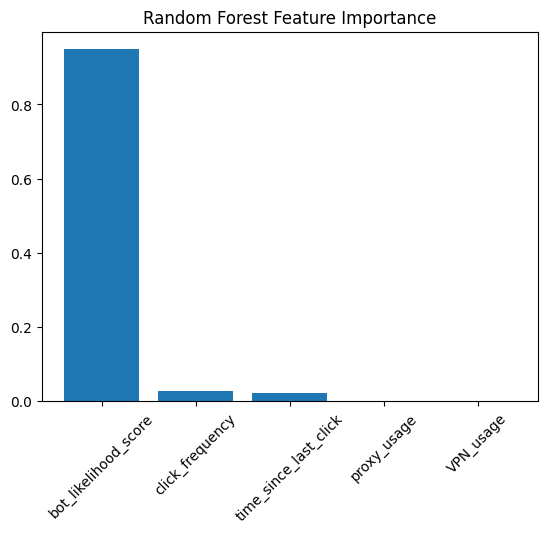

In [10]:
# ==========================================
# Cell 8: Random Forest Feature Importance
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd

rf_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance)

plt.figure()
plt.bar(rf_importance["Feature"], rf_importance["Importance"])
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()


                 Feature  Importance
4   bot_likelihood_score    0.808383
0        click_frequency    0.059326
1  time_since_last_click    0.051204
3            proxy_usage    0.041879
2              VPN_usage    0.039209


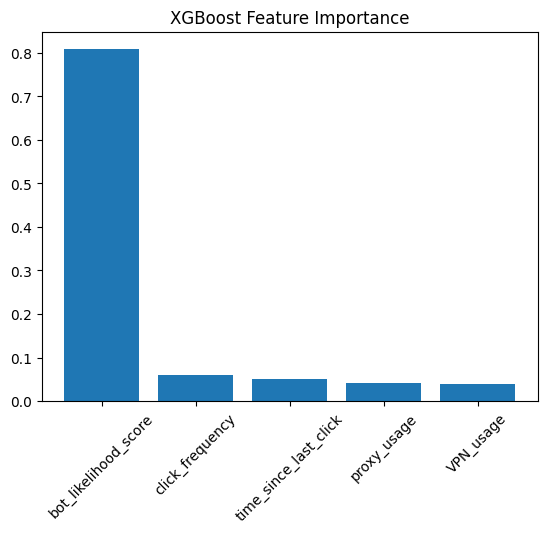

In [11]:
# ==========================================
# Cell 9: XGBoost Feature Importance
# ==========================================

xgb_importance = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(xgb_importance)

plt.figure()
plt.bar(xgb_importance["Feature"], xgb_importance["Importance"])
plt.xticks(rotation=45)
plt.title("XGBoost Feature Importance")
plt.show()


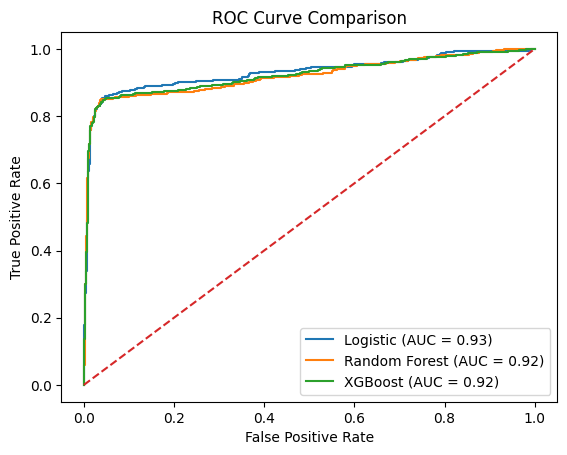

In [12]:
# ==========================================
# Cell 10: ROC Curve Comparison
# ==========================================

from sklearn.metrics import roc_curve, auc

# Predict probabilities
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)

auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


In [13]:
# ==========================================
# Cell 11: Model Comparison Table
# ==========================================

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "AUC": [auc_log, auc_rf, auc_xgb]
})

results


,Model,Accuracy,AUC
0,Logistic Regression,0.848000,0.929516
1,Random Forest,0.931333,0.918924
2,XGBoost,0.932000,0.921661


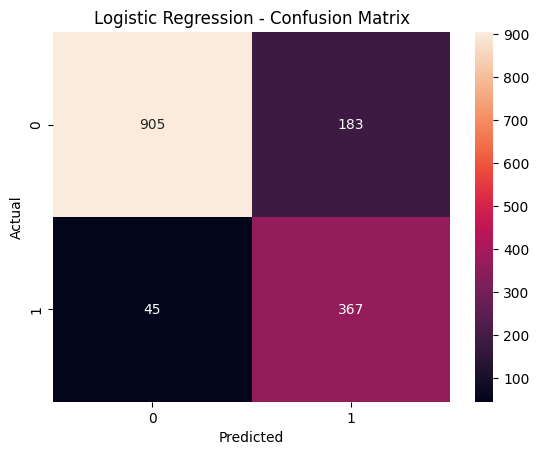

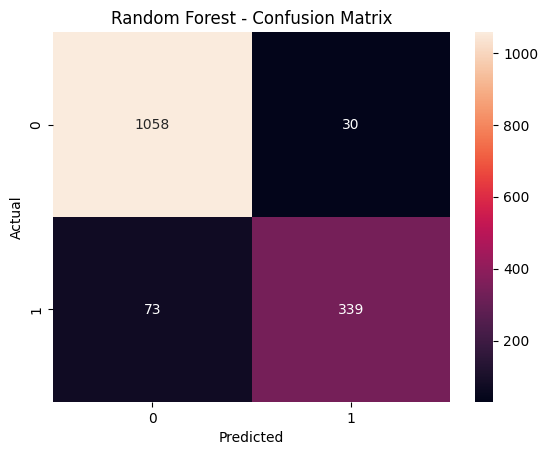

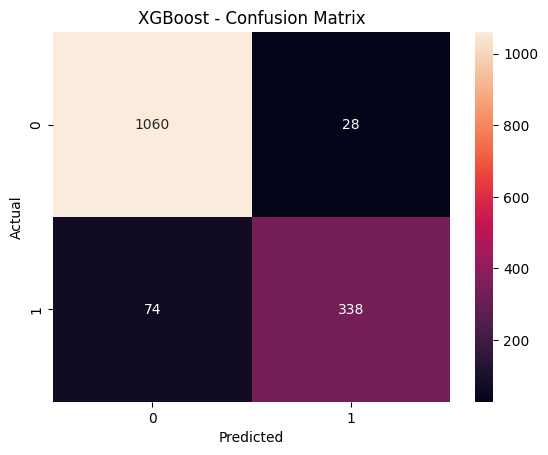

In [14]:
# ==========================================
# Cell 12: Confusion Matrix Heatmaps
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [15]:
# ==========================================
# Cell 13: Cross Validation Scores
# ==========================================

from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(rf_model, X, y, cv=5, scoring="accuracy")
xgb_cv = cross_val_score(xgb_model, X, y, cv=5, scoring="accuracy")

print("Random Forest CV Accuracy:", rf_cv.mean())
print("XGBoost CV Accuracy:", xgb_cv.mean())


Random Forest CV Accuracy: 0.9296
XGBoost CV Accuracy: 0.9296000000000001


In [17]:
# ==========================================
# Cell 14: Save Best Model
# ==========================================

import joblib

joblib.dump(rf_model, "best_fraud_model1.pkl")
print("Model Saved Successfully")


Model Saved Successfully


In [ ]:
df.to_csv("merged_1.csv",index=False)